## Analysing the Results

In [1]:
import os, json
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd


In [2]:
# Load in all the results 
results_file = "../results/all_results.json"

# Load existing results if they exist
if os.path.exists(results_file): # checks if the file exists
    with open(results_file, "r") as f:
        all_results = json.load(f) # if the file exists load the .json

In [3]:
all_results

{'train_LSTM': {'timestamp': '2025-10-18 14:15:07',
  'training_time': 1956.1013114452362,
  'best_metrics': {'loss': 0.5001593996496762,
   'accuracy': 0.8974028366181617,
   'precision_weighted': 0.8968922914561616,
   'recall_weighted': 0.8974028366181617,
   'f1_weighted': 0.8969175519140611,
   'precision_macro': 0.8765178684597489,
   'recall_macro': 0.8662313210832023,
   'f1_macro': 0.8711251171331013,
   'report': {'negative': {'precision': 0.8318318318318318,
     'recall': 0.826865671641791,
     'f1-score': 0.8293413173652695,
     'support': 670.0},
    'neutral': {'precision': 0.9157773291029708,
     'recall': 0.9363019758183426,
     'f1-score': 0.9259259259259259,
     'support': 3391.0},
    'positive': {'precision': 0.8819444444444444,
     'recall': 0.8355263157894737,
     'f1-score': 0.8581081081081081,
     'support': 1368.0},
    'accuracy': 0.8974028366181617,
    'macro avg': {'precision': 0.8765178684597489,
     'recall': 0.8662313210832023,
     'f1-score':

### Analysing Logistic Regression Results

In [4]:
LR_results = all_results['train_LR']
LR_results

{'timestamp': '2025-10-18 18:33:36',
 'training_time': 3.39294695854187,
 'best_metrics': {'accuracy': 0.8541167802541905,
  'precision_weighted': 0.8587353126399472,
  'recall_weighted': 0.8541167802541905,
  'f1_weighted': 0.8557813753574448,
  'precision_macro': 0.8022808628705619,
  'recall_macro': 0.828069345122949,
  'f1_macro': 0.8142284665935565,
  'roc_auc': {'negative': 0.951709722034919,
   'neutral': 0.9352621628168312,
   'positive': 0.9385009093776056,
   'macro': 0.9418242647431185,
   'weighted': 0.9381080773446002},
  'report': {'0': {'precision': 0.6986486486486486,
    'recall': 0.7716417910447761,
    'f1-score': 0.7333333333333333,
    'support': 670.0},
   '1': {'precision': 0.9180277349768875,
    'recall': 0.8785019168386906,
    'f1-score': 0.8978300180831826,
    'support': 3391.0},
   '2': {'precision': 0.7901662049861495,
    'recall': 0.8340643274853801,
    'f1-score': 0.8115220483641536,
    'support': 1368.0},
   'accuracy': 0.8541167802541905,
   'macro

In [5]:
# training time
LR_training_time = LR_results['training_time']

# metrics
LR_metrics = LR_results['best_metrics']
LR_accuracy = LR_metrics['accuracy']
LR_f1 = LR_metrics['f1_weighted']
LR_precision = LR_metrics['precision_weighted']
LR_recall = LR_metrics['recall_weighted']
LR_f1_macro = LR_metrics['f1_macro']
LR_precision_macro = LR_metrics['precision_macro']
LR_recall_macro = LR_metrics['recall_macro']

# fairness report
LR_report = LR_metrics['report']
LR_class_0 = LR_report['0']
LR_class_1 = LR_report['1']
LR_class_2 = LR_report['2']

LR_f1_0 = LR_class_0['f1-score']
LR_precision_0 = LR_class_0['precision']
LR_recall_0 = LR_class_0['recall']

LR_f1_1 = LR_class_1['f1-score']
LR_precision_1 = LR_class_1['precision']
LR_recall_1 = LR_class_1['recall']

LR_f1_2 = LR_class_2['f1-score']
LR_precision_2 = LR_class_2['precision']
LR_recall_2 = LR_class_2['recall']

# confusion matrix
LR_confusion_matrix = np.array(LR_metrics['confusion_matrix'])

# AUC scores
LR_auc = LR_metrics['roc_auc']
LR_auc_negative = LR_auc['negative']
LR_auc_positive = LR_auc['positive']
LR_auc_neutral = LR_auc['neutral']
LR_auc_macro = LR_auc['macro']

# Text examples
LR_examples = LR_metrics['examples']
LR_correct_preds = LR_examples['correct']
LR_wrong_preds = LR_examples['wrong']
LR_correct_neutral = LR_correct_preds['neutral']
LR_wrong_positive = LR_wrong_preds['positive']


### MLP Analysis

In [6]:
MLP_results = all_results['train_MLP']
MLP_results

{'timestamp': '2025-10-18 13:42:09',
 'training_time': 1954.7075657844543,
 'best_metrics': {'loss': 0.5416570533724392,
  'accuracy': 0.8824829618714312,
  'precision_weighted': 0.8818632104749691,
  'recall_weighted': 0.8824829618714312,
  'f1_weighted': 0.8819556551000779,
  'precision_macro': 0.8626880982052781,
  'recall_macro': 0.8447327083302284,
  'f1_macro': 0.8531977365375333,
  'report': {'negative': {'precision': 0.8439024390243902,
    'recall': 0.7746268656716417,
    'f1-score': 0.8077821011673152,
    'support': 670.0},
   'neutral': {'precision': 0.9076655052264808,
    'recall': 0.9218519610734297,
    'f1-score': 0.9147037307973664,
    'support': 3391.0},
   'positive': {'precision': 0.8364963503649635,
    'recall': 0.8377192982456141,
    'f1-score': 0.8371073776479182,
    'support': 1368.0},
   'accuracy': 0.8824829618714312,
   'macro avg': {'precision': 0.8626880982052781,
    'recall': 0.8447327083302284,
    'f1-score': 0.8531977365375333,
    'support': 542

In [7]:
# Training time
MLP_training_time = MLP_results['training_time']

# Metrics
MLP_metrics = MLP_results['best_metrics']
MLP_accuracy = MLP_metrics['accuracy']
MLP_f1 = MLP_metrics['f1_weighted']
MLP_precision = MLP_metrics['precision_weighted']
MLP_recall = MLP_metrics['recall_weighted']
MLP_f1_macro = MLP_metrics['f1_macro']
MLP_precision_macro = MLP_metrics['precision_macro']
MLP_recall_macro = MLP_metrics['recall_macro']
MLP_loss = MLP_metrics['loss']

# Fairness Report
MLP_report = MLP_metrics['report']
MLP_class_0 = MLP_report['negative']
MLP_class_1 = MLP_report['neutral']
MLP_class_2 = MLP_report['positive']

MLP_f1_0 = MLP_class_0['f1-score']
MLP_precision_0 = MLP_class_0['precision']
MLP_recall_0 = MLP_class_0['recall']

MLP_f1_1 = MLP_class_1['f1-score']
MLP_precision_1 = MLP_class_1['precision']
MLP_recall_1 = MLP_class_1['recall']

MLP_f1_2 = MLP_class_2['f1-score']
MLP_precision_2 = MLP_class_2['precision']
MLP_recall_2 = MLP_class_2['recall']

# Confusion Matrix
MLP_confusion_matrix = np.array(MLP_metrics['confusion_matrix'])

# Text examples
MLP_examples = MLP_metrics['examples']
MLP_correct_preds = MLP_examples['correct']
MLP_wrong_preds = MLP_examples['wrong']
MLP_correct_neutral = MLP_correct_preds['neutral']
MLP_wrong_positive = MLP_wrong_preds['positive']

# AUC score
MLP_auc = MLP_metrics['roc_auc']
MLP_auc_negative = MLP_auc['negative']
MLP_auc_positive = MLP_auc['positive']
MLP_auc_neutral = MLP_auc['neutral']
MLP_auc_macro = MLP_auc['macro']

# Training history
MLP_history = MLP_results['history']


### LSTM Results

In [8]:
LSTM_results = all_results['train_LSTM']
LSTM_results

{'timestamp': '2025-10-18 14:15:07',
 'training_time': 1956.1013114452362,
 'best_metrics': {'loss': 0.5001593996496762,
  'accuracy': 0.8974028366181617,
  'precision_weighted': 0.8968922914561616,
  'recall_weighted': 0.8974028366181617,
  'f1_weighted': 0.8969175519140611,
  'precision_macro': 0.8765178684597489,
  'recall_macro': 0.8662313210832023,
  'f1_macro': 0.8711251171331013,
  'report': {'negative': {'precision': 0.8318318318318318,
    'recall': 0.826865671641791,
    'f1-score': 0.8293413173652695,
    'support': 670.0},
   'neutral': {'precision': 0.9157773291029708,
    'recall': 0.9363019758183426,
    'f1-score': 0.9259259259259259,
    'support': 3391.0},
   'positive': {'precision': 0.8819444444444444,
    'recall': 0.8355263157894737,
    'f1-score': 0.8581081081081081,
    'support': 1368.0},
   'accuracy': 0.8974028366181617,
   'macro avg': {'precision': 0.8765178684597489,
    'recall': 0.8662313210832023,
    'f1-score': 0.8711251171331013,
    'support': 5429

In [9]:
# Training time
LSTM_training_time = LSTM_results['training_time']

# Metrics
LSTM_metrics = LSTM_results['best_metrics']
LSTM_accuracy = LSTM_metrics['accuracy']
LSTM_f1 = LSTM_metrics['f1_weighted']
LSTM_precision = LSTM_metrics['precision_weighted']
LSTM_recall = LSTM_metrics['recall_weighted']
LSTM_f1_macro = LSTM_metrics['f1_macro']
LSTM_precision_macro = LSTM_metrics['precision_macro']
LSTM_recall_macro = LSTM_metrics['recall_macro']
LSTM_loss = LSTM_metrics['loss']

# Fairness Report
LSTM_report = LSTM_metrics['report']
LSTM_class_0 = LSTM_report['negative']
LSTM_class_1 = LSTM_report['neutral']
LSTM_class_2 = LSTM_report['positive']

LSTM_f1_0 = LSTM_class_0['f1-score']
LSTM_precision_0 = LSTM_class_0['precision']
LSTM_recall_0 = LSTM_class_0['recall']

LSTM_f1_1 = LSTM_class_1['f1-score']
LSTM_precision_1 = LSTM_class_1['precision']
LSTM_recall_1 = LSTM_class_1['recall']

LSTM_f1_2 = LSTM_class_2['f1-score']
LSTM_precision_2 = LSTM_class_2['precision']
LSTM_recall_2 = LSTM_class_2['recall']

# Confusion Matrix
LSTM_confusion_matrix = np.array(LSTM_metrics['confusion_matrix'])

# Text Examples
LSTM_examples = LSTM_metrics['examples']
LSTM_correct_preds = LSTM_examples['correct']
LSTM_wrong_preds = LSTM_examples['wrong']
LSTM_correct_neutral = LSTM_correct_preds['neutral']
LSTM_wrong_positive = LSTM_wrong_preds['positive']

# AUC score
LSTM_auc = LSTM_metrics['roc_auc']
LSTM_auc_negative = LSTM_auc['negative']
LSTM_auc_positive = LSTM_auc['positive']
LSTM_auc_neutral = LSTM_auc['neutral']
LSTM_auc_macro = LSTM_auc['macro']

# Training History
LSTM_history = LSTM_results['history']

### Transformer Analysis

In [10]:
Transformer_results = all_results['train_transformer']
Transformer_results

{'timestamp': '2025-10-18 14:50:39',
 'training_time': 2113.538218975067,
 'best_metrics': {'loss': 0.4934281201923595,
  'accuracy': 0.9031129121385154,
  'precision_weighted': 0.9033059103546154,
  'recall_weighted': 0.9031129121385154,
  'f1_weighted': 0.9027104046370799,
  'precision_macro': 0.8798687519197861,
  'recall_macro': 0.8738869111460844,
  'f1_macro': 0.8762336691669116,
  'report': {'negative': {'precision': 0.8146551724137931,
    'recall': 0.8462686567164179,
    'f1-score': 0.8301610541727672,
    'support': 670.0},
   'neutral': {'precision': 0.9202648244099021,
    'recall': 0.9427897375405485,
    'f1-score': 0.9313911143481427,
    'support': 3391.0},
   'positive': {'precision': 0.9046862589356632,
    'recall': 0.8326023391812866,
    'f1-score': 0.8671488389798249,
    'support': 1368.0},
   'accuracy': 0.9031129121385154,
   'macro avg': {'precision': 0.8798687519197861,
    'recall': 0.8738869111460844,
    'f1-score': 0.8762336691669116,
    'support': 5429

In [11]:
# Training time
Transformer_training_time = Transformer_results['training_time']

# Metrics
Transformer_metrics = Transformer_results['best_metrics']
Transformer_accuracy = Transformer_metrics['accuracy']
Transformer_f1 = Transformer_metrics['f1_weighted']
Transformer_precision = Transformer_metrics['precision_weighted']
Transformer_recall = Transformer_metrics['recall_weighted']
Transformer_f1_macro = Transformer_metrics['f1_macro']
Transformer_precision_macro = Transformer_metrics['precision_macro']
Transformer_recall_macro = Transformer_metrics['recall_macro']
Transformer_loss = Transformer_metrics['loss']

# Fairness Report
Transformer_report = Transformer_metrics['report']
Transformer_class_0 = Transformer_report['negative']
Transformer_class_1 = Transformer_report['neutral']
Transformer_class_2 = Transformer_report['positive']

Transformer_f1_0 = Transformer_class_0['f1-score']
Transformer_precision_0 = Transformer_class_0['precision']
Transformer_recall_0 = Transformer_class_0['recall']

Transformer_f1_1 = Transformer_class_1['f1-score']
Transformer_precision_1 = Transformer_class_1['precision']
Transformer_recall_1 = Transformer_class_1['recall']

Transformer_f1_2 = Transformer_class_2['f1-score']
Transformer_precision_2 = Transformer_class_2['precision']
Transformer_recall_2 = Transformer_class_2['recall']

# Confusion Matrix
Transformer_confusion_matrix = np.array(Transformer_metrics['confusion_matrix'])

# Text Examples
Transformer_examples = Transformer_metrics['examples']
Transformer_correct_preds = Transformer_examples['correct']
Transformer_wrong_preds = Transformer_examples['wrong']
Transformer_correct_neutral = Transformer_correct_preds['neutral']
Transformer_wrong_positive = Transformer_wrong_preds['positive']

# AUC score
Transformer_auc = Transformer_metrics['roc_auc']
Transformer_auc_negative = Transformer_auc['negative']
Transformer_auc_positive = Transformer_auc['positive']
Transformer_auc_neutral = Transformer_auc['neutral']
Transformer_auc_macro = Transformer_auc['macro']

# Training history
Transformer_history = Transformer_results['history']


## Comparative Eval

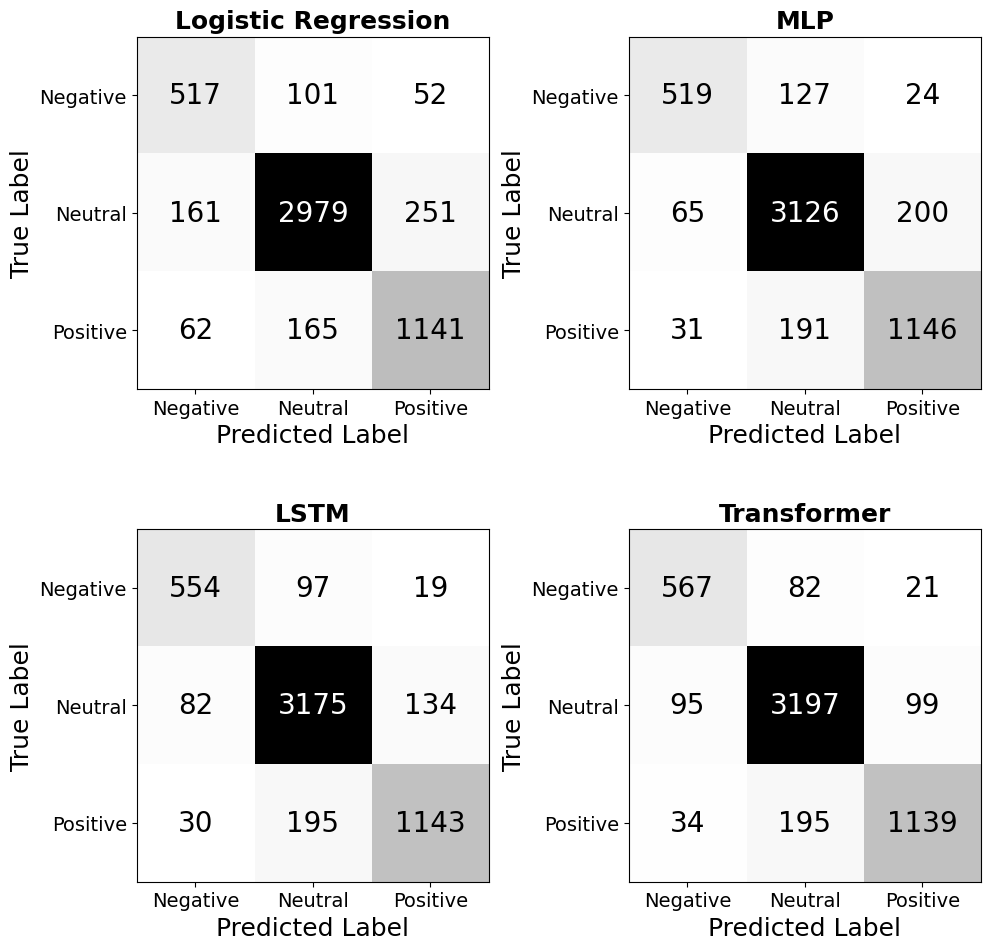

In [20]:
# Create ConfusionMatrixDisplay objects
LR_conf_matrix = ConfusionMatrixDisplay(LR_confusion_matrix, display_labels=['Negative', 'Neutral', 'Positive'])
MLP_conf_matrix = ConfusionMatrixDisplay(MLP_confusion_matrix, display_labels=['Negative', 'Neutral', 'Positive'])
LSTM_conf_matrix = ConfusionMatrixDisplay(LSTM_confusion_matrix, display_labels=['Negative', 'Neutral', 'Positive'])
Transformer_conf_matrix = ConfusionMatrixDisplay(Transformer_confusion_matrix, display_labels=['Negative', 'Neutral', 'Positive'])

# Create 2x2 layout
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Plot each confusion matrix in greyscale
LR_conf_matrix.plot(ax=axes[0, 0], cmap='Greys', colorbar=False)
MLP_conf_matrix.plot(ax=axes[0, 1], cmap='Greys', colorbar=False)
LSTM_conf_matrix.plot(ax=axes[1, 0], cmap='Greys', colorbar=False)
Transformer_conf_matrix.plot(ax=axes[1, 1], cmap='Greys', colorbar=False)

# Add titles
axes[0, 0].set_title("Logistic Regression", fontsize=18, weight='bold')
axes[0, 1].set_title("MLP", fontsize=18, weight='bold')
axes[1, 0].set_title("LSTM", fontsize=18, weight='bold')
axes[1, 1].set_title("Transformer", fontsize=18, weight='bold')

# Remove redundant axis labels
for ax in axes.flat:
    ax.set_xlabel('Predicted Label', fontsize=18)
    ax.set_ylabel('True Label', fontsize=18)
    ax.tick_params(axis='both', which='major', labelsize=14)  
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_edgecolor('black')

# Adjust font size of text in confusion matrices
for ax in axes.flat:
    for text in ax.texts:
        text.set_fontsize(20) 

plt.tight_layout()
plt.savefig("../results/figures/confusion_matrices.png", bbox_inches='tight')
plt.savefig("../results/figures/confusion_matrices.pdf", bbox_inches='tight')


plt.show()


In [13]:
import pandas as pd
import numpy as np

# Convert training time (seconds → minutes)
LR_train_mins = LR_training_time / 60
MLP_train_mins = MLP_training_time / 60
LSTM_train_mins = LSTM_training_time / 60
Transformer_train_mins = Transformer_training_time / 60

# Summary Table — concise high-level metrics
summary_data = {
    'Metric': [
        'Accuracy',
        'Precision (Weighted)', 'Recall (Weighted)', 'F1 (Weighted)',
        'Precision (Macro)', 'Recall (Macro)', 'F1 (Macro)',
        'ROC-AUC (Macro)', 'Loss', 'Training Time (min)'
    ],
    'Logistic Regression': [
        LR_accuracy, LR_precision, LR_recall, LR_f1,
        LR_precision_macro, LR_recall_macro, LR_f1_macro,
        LR_auc_macro, None, LR_train_mins
    ],
    'MLP': [
        MLP_accuracy, MLP_precision, MLP_recall, MLP_f1,
        MLP_precision_macro, MLP_recall_macro, MLP_f1_macro,
        MLP_auc_macro, MLP_loss, MLP_train_mins
    ],
    'LSTM': [
        LSTM_accuracy, LSTM_precision, LSTM_recall, LSTM_f1,
        LSTM_precision_macro, LSTM_recall_macro, LSTM_f1_macro,
        LSTM_auc_macro, LSTM_loss, LSTM_train_mins
    ],
    'Transformer': [
        Transformer_accuracy, Transformer_precision, Transformer_recall, Transformer_f1,
        Transformer_precision_macro, Transformer_recall_macro, Transformer_f1_macro,
        Transformer_auc_macro, Transformer_loss, Transformer_train_mins
    ]
}

summary_df = pd.DataFrame(summary_data).round(3)

# Save concise summary
summary_path_csv = "../results/figures/summary_results.csv"
summary_path_tex = "../results/figures/summary_results.tex"

summary_df.to_csv(summary_path_csv, index=False)
with open(summary_path_tex, "w") as f:
    f.write(summary_df.to_latex(
        index=False,
        caption="Summary of Model Performance Across All Architectures",
        label="tab:summary_results",
        float_format="%.3f",
        na_rep="--",
        column_format="lcccc"
    ))

print(f"Saved concise summary table:\n- {summary_path_csv}\n- {summary_path_tex}")
print(summary_df)


# Appendix Table — detailed with per-class metrics

appendix_data = {
    'Metric': [
        # Overall metrics
        'Accuracy',
        # Negative class
        'Precision (Negative)', 'Recall (Negative)', 'F1 (Negative)',
        # Neutral class
        'Precision (Neutral)', 'Recall (Neutral)', 'F1 (Neutral)',
        # Positive class
        'Precision (Positive)', 'Recall (Positive)', 'F1 (Positive)',
        # Macro
        'Precision (Macro)', 'Recall (Macro)', 'F1 (Macro)',
        # Weighted
        'Precision (Weighted)', 'Recall (Weighted)', 'F1 (Weighted)',
        # AUCs
        'ROC-AUC (Negative)', 'ROC-AUC (Neutral)', 'ROC-AUC (Positive)', 'ROC-AUC (Macro)',
        # Other
        'Loss', 'Training Time (min)'
    ],
    'Logistic Regression': [
        LR_accuracy,
        LR_precision_0, LR_recall_0, LR_f1_0,
        LR_precision_1, LR_recall_1, LR_f1_1,
        LR_precision_2, LR_recall_2, LR_f1_2,
        LR_precision_macro, LR_recall_macro, LR_f1_macro,
        LR_precision, LR_recall, LR_f1,
        LR_auc_negative, LR_auc_neutral, LR_auc_positive, LR_auc_macro,
        None, LR_train_mins
    ],
    'MLP': [
        MLP_accuracy,
        MLP_precision_0, MLP_recall_0, MLP_f1_0,
        MLP_precision_1, MLP_recall_1, MLP_f1_1,
        MLP_precision_2, MLP_recall_2, MLP_f1_2,
        MLP_precision_macro, MLP_recall_macro, MLP_f1_macro,
        MLP_precision, MLP_recall, MLP_f1,
        MLP_auc_negative, MLP_auc_neutral, MLP_auc_positive, MLP_auc_macro,
        MLP_loss, MLP_train_mins
    ],
    'LSTM': [
        LSTM_accuracy,
        LSTM_precision_0, LSTM_recall_0, LSTM_f1_0,
        LSTM_precision_1, LSTM_recall_1, LSTM_f1_1,
        LSTM_precision_2, LSTM_recall_2, LSTM_f1_2,
        LSTM_precision_macro, LSTM_recall_macro, LSTM_f1_macro,
        LSTM_precision, LSTM_recall, LSTM_f1,
        LSTM_auc_negative, LSTM_auc_neutral, LSTM_auc_positive, LSTM_auc_macro,
        LSTM_loss, LSTM_train_mins
    ],
    'Transformer': [
        Transformer_accuracy,
        Transformer_precision_0, Transformer_recall_0, Transformer_f1_0,
        Transformer_precision_1, Transformer_recall_1, Transformer_f1_1,
        Transformer_precision_2, Transformer_recall_2, Transformer_f1_2,
        Transformer_precision_macro, Transformer_recall_macro, Transformer_f1_macro,
        Transformer_precision, Transformer_recall, Transformer_f1,
        Transformer_auc_negative, Transformer_auc_neutral, Transformer_auc_positive, Transformer_auc_macro,
        Transformer_loss, Transformer_train_mins
    ]
}

appendix_df = pd.DataFrame(appendix_data).round(3)

# Save appendix
appendix_path_csv = "../results/figures/full_appendix_metrics.csv"
appendix_path_tex = "../results/figures/full_appendix_metrics.tex"

appendix_df.to_csv(appendix_path_csv, index=False)
with open(appendix_path_tex, "w") as f:
    f.write(appendix_df.to_latex(
        index=False,
        caption="Detailed Per-Class and Overall Performance Metrics Across All Models",
        label="tab:full_appendix_metrics",
        float_format="%.3f",
        na_rep="--",
        column_format="lcccc"
    ))

print(f"\nSaved full appendix table:\n- {appendix_path_csv}\n- {appendix_path_tex}")
print(appendix_df.head(15))


Saved concise summary table:
- ../results/figures/summary_results.csv
- ../results/figures/summary_results.tex
                 Metric  Logistic Regression     MLP    LSTM  Transformer
0              Accuracy                0.854   0.882   0.897        0.903
1  Precision (Weighted)                0.859   0.882   0.897        0.903
2     Recall (Weighted)                0.854   0.882   0.897        0.903
3         F1 (Weighted)                0.856   0.882   0.897        0.903
4     Precision (Macro)                0.802   0.863   0.877        0.880
5        Recall (Macro)                0.828   0.845   0.866        0.874
6            F1 (Macro)                0.814   0.853   0.871        0.876
7       ROC-AUC (Macro)                0.942   0.962   0.966        0.969
8                  Loss                  NaN   0.542   0.500        0.493
9   Training Time (min)                0.057  32.578  32.602       35.226

Saved full appendix table:
- ../results/figures/full_appendix_metrics.csv


In [14]:
SAVE_PATH = "../results/figures/text_analysis.tex"
NEWLINE_SEPARATOR = "    |   " 

# Extract the model examples
def extract_model_examples(model_name, model_data):
    examples = model_data['best_metrics']['examples']
    rows = []
    
    for sentiment in ['neutral', 'negative', 'positive']:
        for ex in examples.get('correct', {}).get(sentiment, []):
            rows.append({
                'Model': model_name, 'Type': 'Correct', 
                'True': sentiment.capitalize(), 'Pred': sentiment.capitalize(), 
                'Text': ex['text'] 
            })
    
    for sentiment in ['neutral', 'negative', 'positive']:
        for ex in examples.get('wrong', {}).get(sentiment, []):
            rows.append({
                'Model': model_name, 'Type': 'Wrong', 
                'True': sentiment.capitalize(), 'Pred': ex.get('pred', 'N/A').capitalize(), 
                'Text': ex['text'] 
            })
    return rows

# Data Extraction and Grouping
all_rows = []
model_names = {
    'train_LSTM': 'LSTM', 'train_MLP': 'MLP', 
    'train_transformer': 'Transformer', 'train_LR': 'LR'
}

for model_key, model_display_name in model_names.items():
    if model_key in all_results:
        all_rows.extend(extract_model_examples(model_display_name, all_results[model_key]))

df = pd.DataFrame(all_rows)

# Group and aggregate using the raw LaTeX newline command.
grouped_df = df.groupby(['Model', 'Type', 'True', 'Pred'])['Text'].apply(
    lambda x: NEWLINE_SEPARATOR.join(x)
).reset_index().rename(columns={'Text': 'Text Examples'})


In [15]:
# Define the FINAL longtable structure, using the required 16.5cm width.
COLUMN_FORMAT = "p{1.8cm}p{1.5cm}p{1.8cm}p{1.8cm}p{16.5cm}"

latex_header = rf"""\begin{{longtable}}{{{COLUMN_FORMAT}}}
\caption{{Prediction Examples By Model}} \label{{tab:text_analysis}} \\
\toprule
\textbf{{Model}} & \textbf{{Type}} & \textbf{{True}} & \textbf{{Pred}} & \textbf{{Text Examples}} \\
\midrule
\endfirsthead

\multicolumn{{5}}{{c}}{{\bfseries Table \thetable\ continued from previous page}} \\
\toprule
\textbf{{Model}} & \textbf{{Type}} & \textbf{{True}} & \textbf{{Pred}} & \textbf{{Text Examples}} \\
\midrule
\endhead

\midrule
\multicolumn{{5}}{{r}}{{\textit{{Continued on next page}}}} \\
\endfoot

\bottomrule
\endlastfoot
"""

# construct the latex rows
latex_body_rows = []
for index, row in grouped_df.iterrows():
    row_string = f"{row['Model']} & {row['Type']} & {row['True']} & {row['Pred']} & {row['Text Examples']} \\\\"
    latex_body_rows.append(row_string)


with open(SAVE_PATH, "w") as f:
    # longtable header structure
    f.write(latex_header)
        
    # add rows to the latex file
    f.write("\n".join(latex_body_rows))
    
    # end longtable
    f.write("\n" + r"\end{longtable}")

In [16]:
grouped_df

,Model,Type,True,Pred,Text Examples
0,LR,Correct,Negative,Negative,Finnish technology company Raute Corporation i...
1,LR,Correct,Neutral,Neutral,Nike sets strategy in South America | The...
2,LR,Correct,Positive,Positive,Ramirent is a leading company in machinery and...
3,LR,Wrong,Negative,Neutral,BXC Form S3 BlueLinx Holdings Inc.
4,LR,Wrong,Negative,Positive,"Profit before taxes was EUR 4.0 mn , down from..."
5,LR,Wrong,Neutral,Negative,2020 the year investors fall in love with stoc...
6,LR,Wrong,Neutral,Positive,The goal is significant expansion in Finland a...
7,LR,Wrong,Positive,Negative,The growth of net sales in the first half of 2...
8,LR,Wrong,Positive,Neutral,The expansion includes the doubling of the flo...
9,LSTM,Correct,Negative,Negative,Finnish technology company Raute Corporation i...


In [17]:
MLP_history
LSTM_history
Transformer_history

{'train_loss': [0.5891359206508188,
  0.5439099701888421,
  0.5221484534880694,
  0.504175239713753,
  0.48742394815472995,
  0.47215232822824926,
  0.45430714715929593,
  0.44119607762378804,
  0.42991039647775536,
  0.41911887281081256,
  0.40796809897703284,
  0.3997629306772176,
  0.38632424947093513,
  0.38567178608740077,
  0.3627698069986175,
  0.35302397976903355],
 'val_loss': [0.5538869433543261,
  0.5420821919160731,
  0.5191261081134572,
  0.513992306765388,
  0.5230737854452694,
  0.5036589468226713,
  0.5088169928859262,
  0.5193731188774109,
  0.4995077858952915,
  0.5030000591979308,
  0.4934281201923595,
  0.4969656807534835,
  0.5159851821029887,
  0.5035518839078791,
  0.5069197149837719,
  0.49848048651919646],
 'accuracy': [0.8528274083624977,
  0.8664579112175355,
  0.8775096702891877,
  0.8870878614846196,
  0.8764044943820225,
  0.8935347209430834,
  0.8876404494382022,
  0.893718916927611,
  0.8955608767728863,
  0.8975870326026892,
  0.9031129121385154,
  0.89

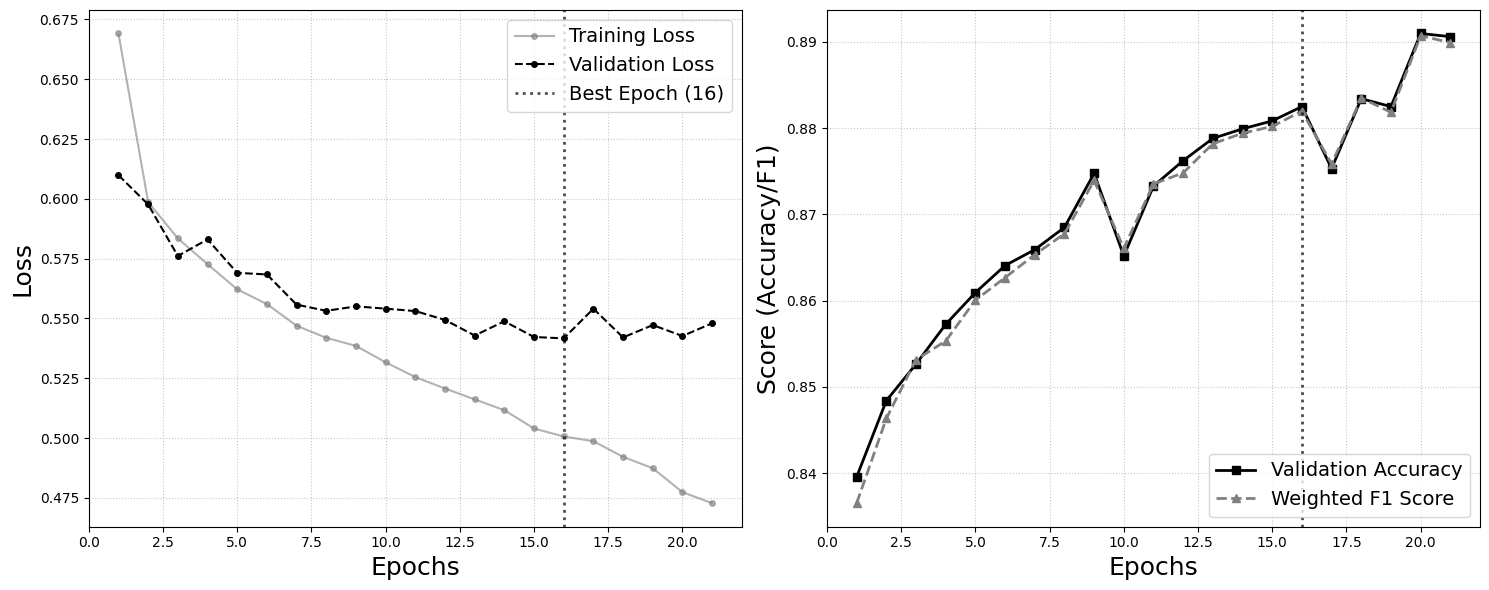

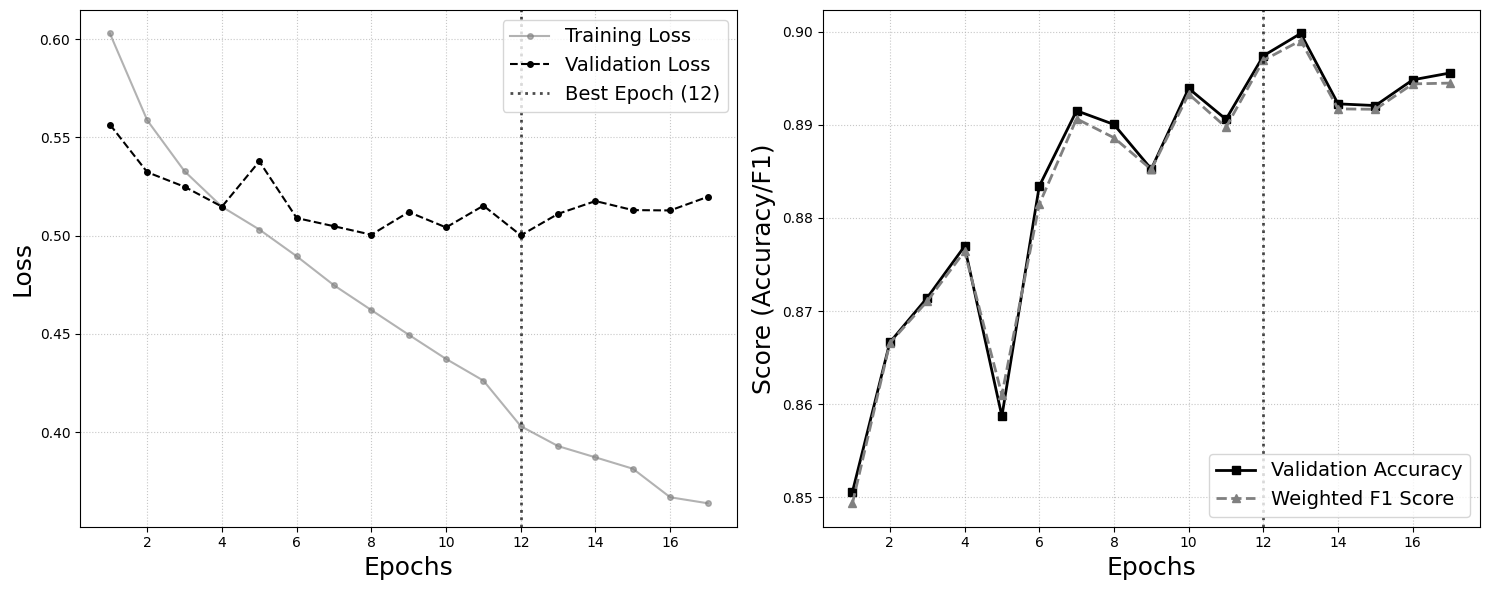

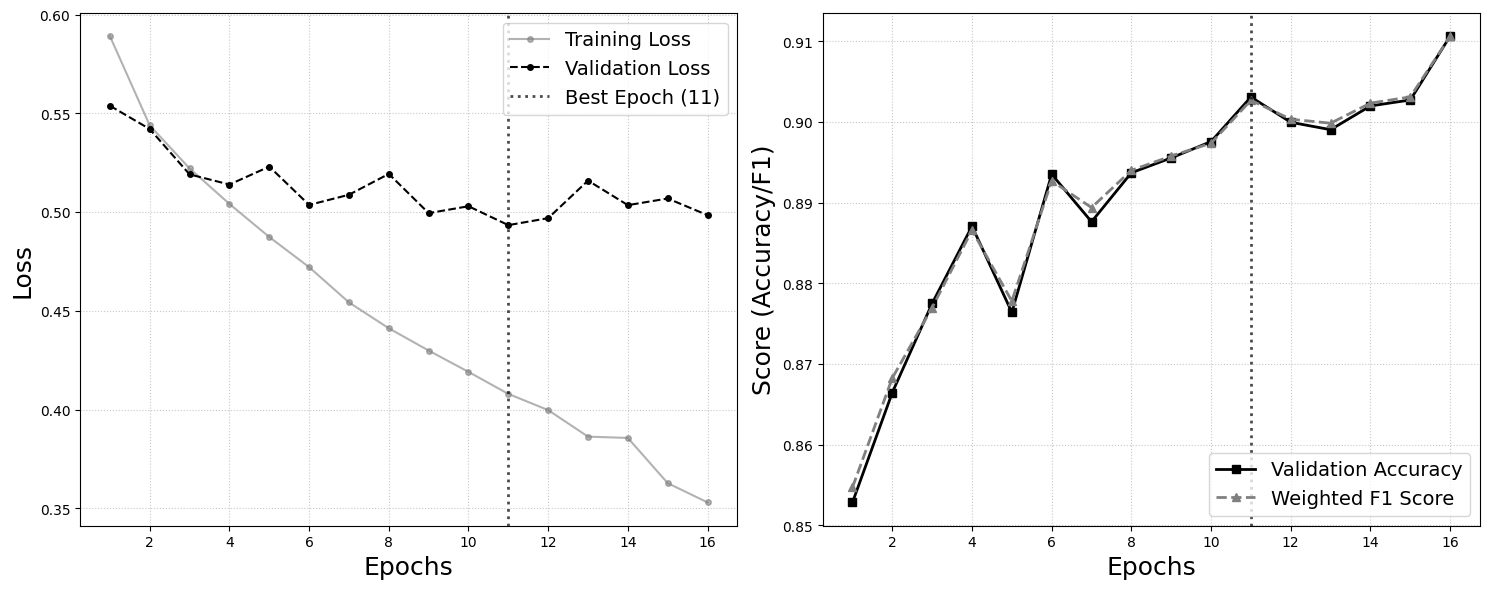

In [18]:
import matplotlib.pyplot as plt
import json
import numpy as np

# Define the models and their keys
MODELS_TO_PLOT = {
    'train_MLP': 'MLP',
    'train_LSTM': 'LSTM',
    'train_transformer': 'Transformer'
}

# Define styling using black and white/grayscale
STYLING = {
    'TRAIN_LOSS':   {'color': 'gray', 'linestyle': '-', 'marker': 'o'},
    'VAL_LOSS':     {'color': 'black', 'linestyle': '--', 'marker': 'o'},
    'ACCURACY':     {'color': 'black', 'linestyle': '-', 'marker': 's'},
    'F1_WEIGHTED':  {'color': 'gray', 'linestyle': '--', 'marker': '^'}
}

# Helper Function to Find Best Epoch

def find_best_epoch(history_dict):

    val_loss = history_dict.get('val_loss')
    if not val_loss:
        return None
    
    best_epoch_index = np.argmin(val_loss)
    
    return best_epoch_index + 1

# Plotting Function for Single Model
def plot_single_model_history(history_dict, model_key, model_name):

    # Extract data
    train_loss = history_dict.get('train_loss')
    val_loss = history_dict.get('val_loss')
    accuracy = history_dict.get('accuracy')
    f1_weighted = history_dict.get('f1_weighted')
          
    epochs = np.arange(1, len(train_loss) + 1)
    best_epoch = find_best_epoch(history_dict)

    plt.figure(figsize=(15, 6))
    
    # LOSS 
    plt.subplot(1, 2, 1)
    
    # Plot Training Loss
    plt.plot(epochs, train_loss, 
             label='Training Loss', 
             color=STYLING['TRAIN_LOSS']['color'], 
             linestyle=STYLING['TRAIN_LOSS']['linestyle'], 
             marker=STYLING['TRAIN_LOSS']['marker'], 
             markersize=4,
             alpha=0.6)
             
    # Plot Validation Loss
    if val_loss:
        plt.plot(epochs, val_loss, 
                 label='Validation Loss', 
                 color=STYLING['VAL_LOSS']['color'], 
                 linestyle=STYLING['VAL_LOSS']['linestyle'], 
                 marker=STYLING['VAL_LOSS']['marker'],
                 markersize=4,
                 alpha=1.0)

    # Mark Best Epoch
    if best_epoch is not None:
        plt.axvline(x=best_epoch, 
                    color='black', 
                    linestyle=':', 
                    linewidth=2, 
                    alpha=0.7, 
                    label=f'Best Epoch ({best_epoch})')

    plt.xlabel('Epochs', fontsize=18)
    plt.ylabel('Loss', fontsize=18)
    plt.legend(loc='upper right', fontsize=14)
    plt.grid(True, linestyle=':', alpha=0.7)

    # ACCURACY and F1 SCORE
    plt.subplot(1, 2, 2)
    
    # Plot Validation Accuracy
    plt.plot(epochs, accuracy, 
             label='Validation Accuracy', 
             color=STYLING['ACCURACY']['color'], 
             linestyle=STYLING['ACCURACY']['linestyle'],
             marker=STYLING['ACCURACY']['marker'],
             markersize=6,
             linewidth=2.0)

    # Plot Weighted F1 Score
    plt.plot(epochs, f1_weighted, 
             label='Weighted F1 Score', 
             color=STYLING['F1_WEIGHTED']['color'], 
             linestyle=STYLING['F1_WEIGHTED']['linestyle'],
             marker=STYLING['F1_WEIGHTED']['marker'],
             markersize=6,
             linewidth=2.0)
    
    # Mark Best Epoch (Early Stopping)
    if best_epoch is not None:
        plt.axvline(x=best_epoch, 
                    color='black', 
                    linestyle=':', 
                    linewidth=2, 
                    alpha=0.7)

    plt.xlabel('Epochs', fontsize=18)
    plt.ylabel('Score (Accuracy/F1)', fontsize=18)
    plt.legend(loc='lower right', fontsize=14)
    plt.grid(True, linestyle=':', alpha=0.7)

    plt.tight_layout()
    
    file_name = f"../results/figures/{model_name.lower()}_training_history.png"
    plt.savefig(file_name)


# create the plots

# Iterate and generate plots for all specified models
for model_key, model_name in MODELS_TO_PLOT.items():
    history = all_results.get(model_key, {}).get('history', {})
    if history:
        plot_single_model_history(history, model_key, model_name)
